# Cluster summary matrix — within-cluster positional entropy

For one checkpoint: assign every ISM variant to its GMM cluster, then for each cluster compute the per-position Shannon entropy (bits) of the member sequences. Low entropy = a position the cluster holds fixed (conserved motif); high entropy = a position free to vary. Heatmap: clusters (y) x position (x).

In [17]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

RESULTS_DIR = "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/results"
SEAM_DIR    = "/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT = "peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3"
ADAPTER = 15   # 15bp adapter each side: context for inference/ISM only, NOT attributed and NOT in the 800-D VAE input


class VAE_GMM_eval(nn.Module):
    def __init__(self, D, J, K, hidden, has_dropout):
        super().__init__()
        if has_dropout:
            self.enc = nn.Sequential(nn.Linear(D, hidden), nn.ReLU(), nn.Dropout(0.0),
                                     nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(0.0))
        else:
            self.enc = nn.Sequential(nn.Linear(D, hidden), nn.ReLU(),
                                     nn.Linear(hidden, hidden), nn.ReLU())
        self.enc_mu = nn.Linear(hidden, J)
        self.enc_lv = nn.Linear(hidden, J)
        self.dec = nn.Sequential(nn.Linear(J, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, D))
        self.mu_b      = nn.Parameter(torch.zeros(D))
        self.mu_c      = nn.Parameter(torch.zeros(K, J))
        self.log_var_c = nn.Parameter(torch.zeros(K, J))
        self.alpha_raw = nn.Parameter(torch.zeros(K))

    @property
    def alpha(self):
        return F.softplus(self.alpha_raw) + 1e-4


# ----- rebuild model, assign every variant to its hard GMM cluster -----
peak    = CKPT.split(".100k")[0].split(".200k")[0]
lib     = "200k" if ".200k" in CKPT else "100k"
preproc = "znorm" if "znorm" in CKPT else "raw"
suffix  = {"100k": "", "200k": "_200k"}[lib]

sd = torch.load(f"{RESULTS_DIR}/{CKPT}.pt", map_location=DEVICE, weights_only=False)["state_dict"]
model = VAE_GMM_eval(sd["enc.0.weight"].shape[1], sd["enc_mu.weight"].shape[0], sd["mu_c"].shape[0],
                     sd["enc.0.weight"].shape[0], "enc.3.weight" in sd)
model.load_state_dict(sd, strict=False); model.eval().to(DEVICE)

with h5py.File(f"{SEAM_DIR}/ism{suffix}/{peak}.h5") as f:
    X = f["ism_centered"][:].reshape(-1, sd["enc.0.weight"].shape[1]).astype(np.float32)
if preproc == "znorm":
    X = (X - X.mean()) / (X.std() + 1e-8)

alpha = model.alpha
Elog_pi = torch.digamma(alpha) - torch.digamma(alpha.sum())
lv_c, mu_c = model.log_var_c[None], model.mu_c[None]
with torch.no_grad():
    h = model.enc(torch.from_numpy(X).to(DEVICE))
    mu_z, lv_z = model.enc_mu(h)[:, None, :], model.enc_lv(h)[:, None, :]
    KL_k = 0.5 * (lv_c - lv_z + (torch.exp(lv_z) + (mu_z - mu_c)**2) * torch.exp(-lv_c) - 1.0).sum(-1)
    hard = (Elog_pi[None] - KL_k).argmax(1).cpu().numpy()

# ----- per-cluster per-position entropy of the member one-hot sequences (core only, adapters cropped) -----
with h5py.File(f"{SEAM_DIR}/mutagenesis_lib{suffix}/{peak}.h5") as f:
    onehot = f["sequences"][:][:, ADAPTER:-ADAPTER]        # (N, 200, 4) core, aligned to attribution positions 0..199

alive = sorted(np.unique(hard), key=lambda k: (hard == k).sum(), reverse=True)   # largest first
entropy = np.zeros((len(alive), onehot.shape[1]))
for i, k in enumerate(alive):
    p = onehot[hard == k].mean(0)                           # (L, 4) base frequencies
    entropy[i] = -(p * np.log2(p + 1e-12)).sum(1)           # (L,) bits, 0..2
print(f"{CKPT}\n{len(alive)} clusters x {onehot.shape[1]} positions")

peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3
20 clusters x 200 positions


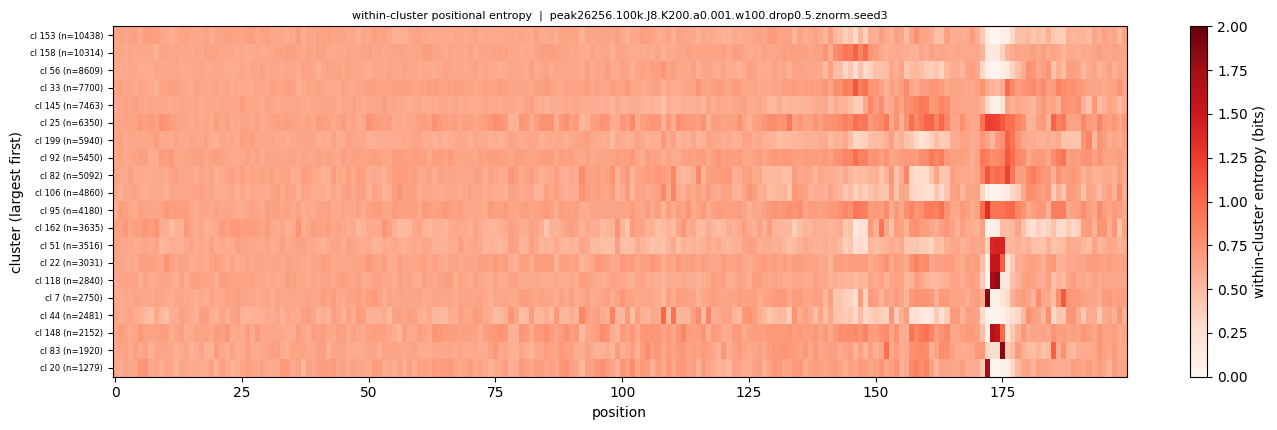

In [18]:
plt.figure(figsize=(14, max(4, 0.22 * len(alive))))
plt.imshow(entropy, aspect="auto", cmap="Reds", vmin=0, vmax=2, interpolation="nearest")
plt.colorbar(label="within-cluster entropy (bits)")
plt.yticks(range(len(alive)), [f"cl {k} (n={(hard == k).sum()})" for k in alive], fontsize=6)
plt.xlabel("position"); plt.ylabel("cluster (largest first)")
plt.title(f"within-cluster positional entropy  |  {CKPT}", fontsize=8)
plt.tight_layout(); plt.show()

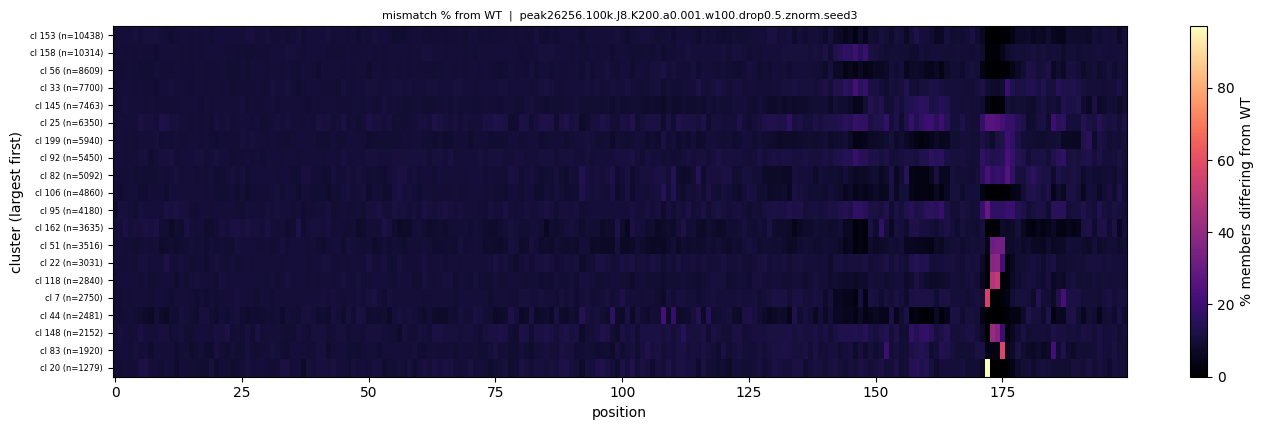

In [19]:
# ----- same matrix but mismatch % from WT: fraction of members differing from the WT base per position -----
with h5py.File(f"{SEAM_DIR}/mutagenesis_lib{suffix}/{peak}.h5") as f:
    wt_seq = f["wt_sequence"][:][ADAPTER:-ADAPTER].argmax(1)   # (200,) WT base per core position
mism_all = onehot.argmax(2) != wt_seq                       # (N, 200) does variant differ from WT here

mismatch = np.zeros((len(alive), onehot.shape[1]))
for i, k in enumerate(alive):
    mismatch[i] = mism_all[hard == k].mean(0) * 100         # (L,) % of members mutated vs WT

plt.figure(figsize=(14, max(4, 0.22 * len(alive))))
plt.imshow(mismatch, aspect="auto", cmap="magma", vmin=0, interpolation="nearest")
plt.colorbar(label="% members differing from WT")
plt.yticks(range(len(alive)), [f"cl {k} (n={(hard == k).sum()})" for k in alive], fontsize=6)
plt.xlabel("position"); plt.ylabel("cluster (largest first)")
plt.title(f"mismatch % from WT  |  {CKPT}", fontsize=8)
plt.tight_layout(); plt.show()

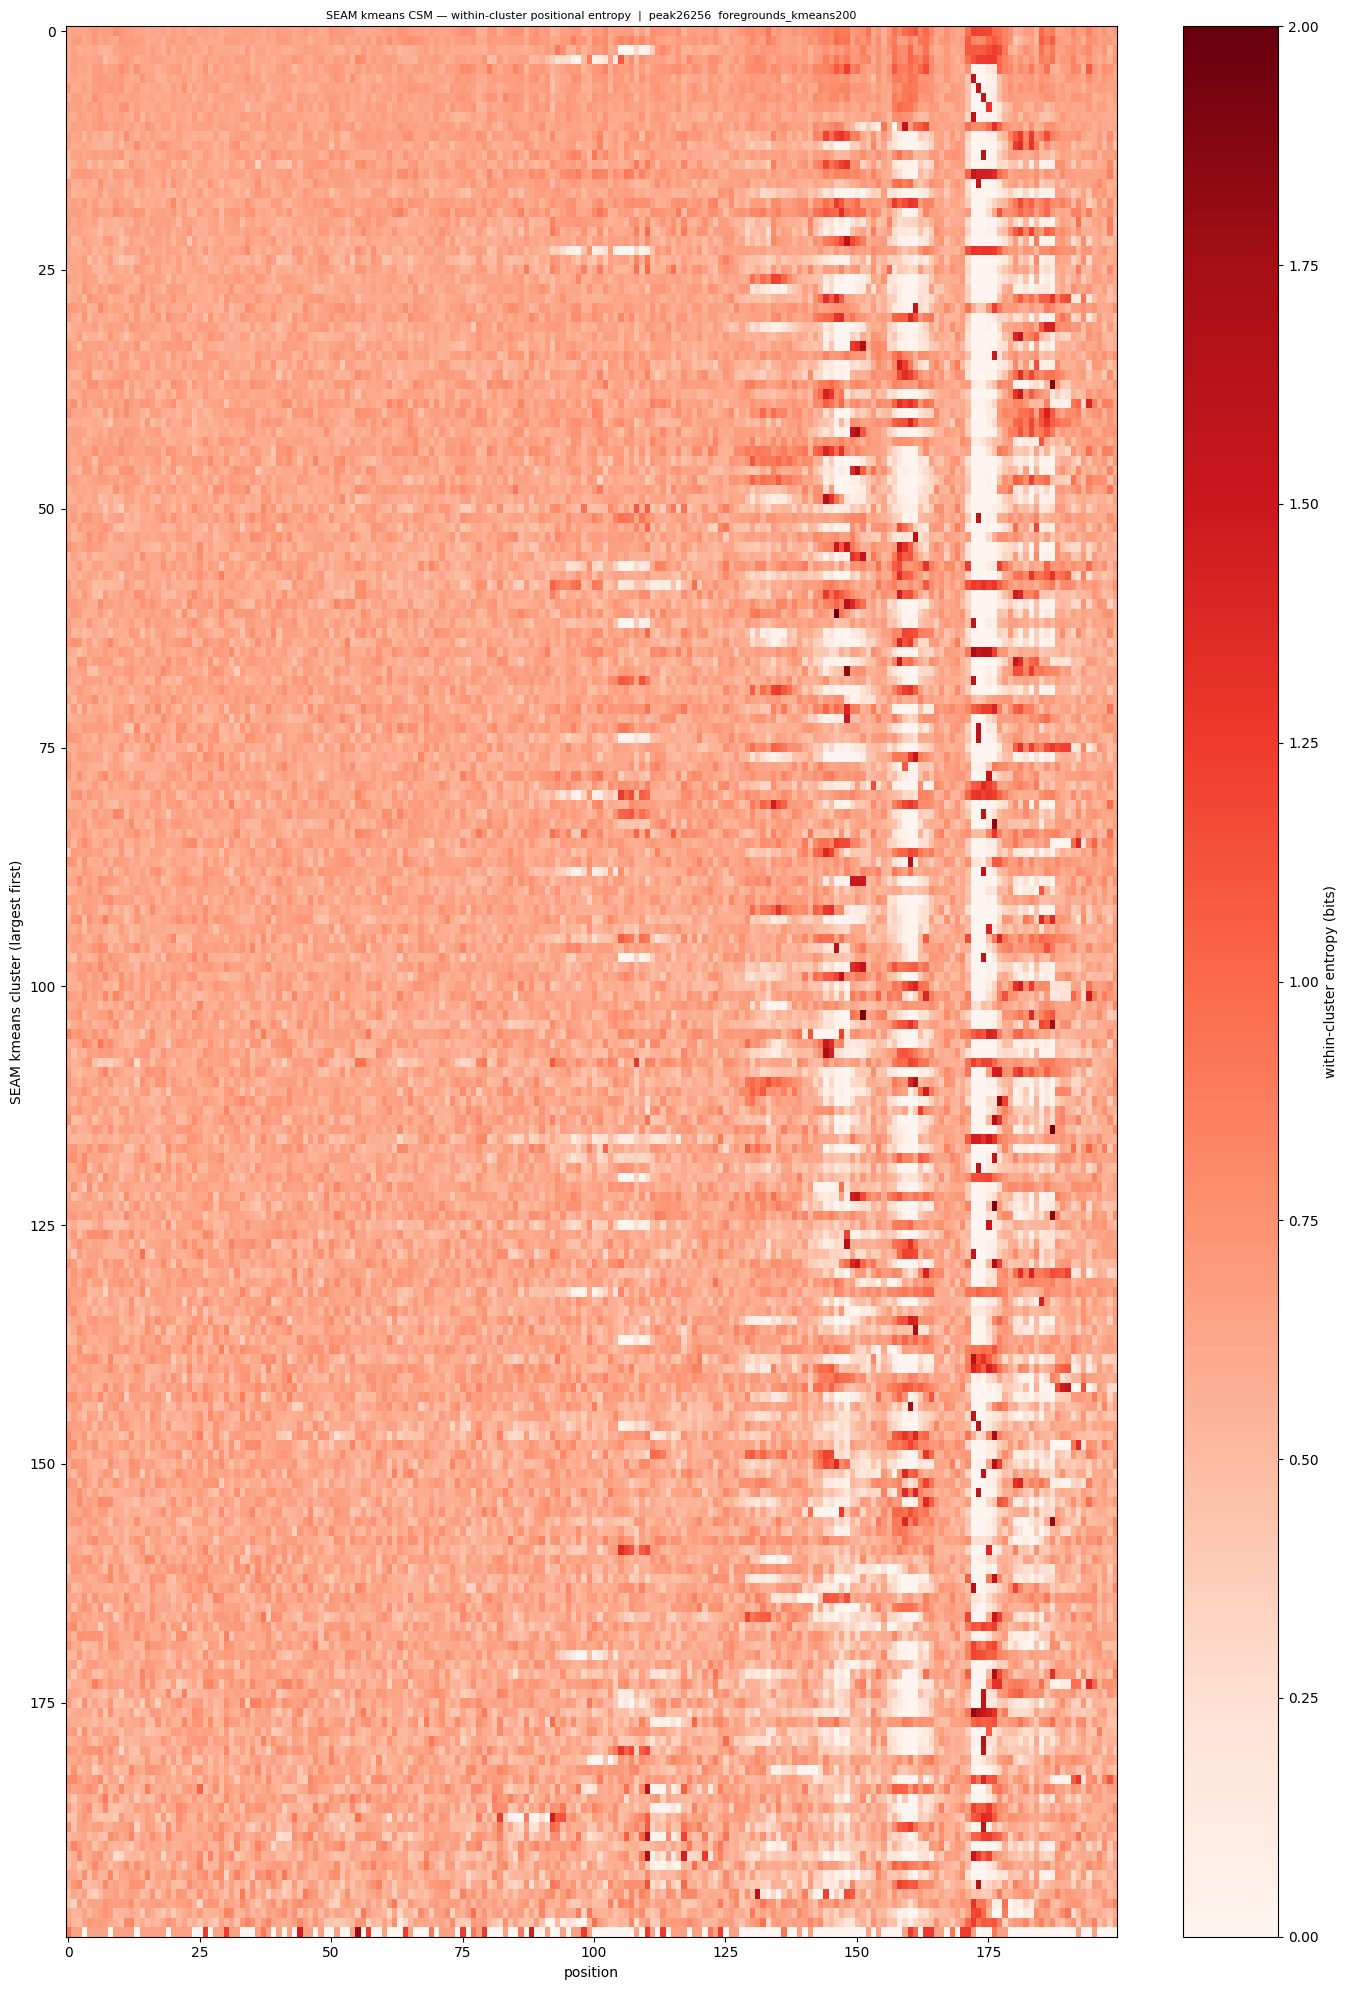

In [20]:
# ----- SEAM's own kmeans clustering: same within-cluster entropy CSM, for comparison -----
SEAM_KM = "foregrounds_kmeans200"                          # precomputed SEAM kmeans on the same library (swap K here)
km = np.load(f"{SEAM_DIR}/{SEAM_KM}/{peak}/cluster_labels.npy")   # (N,) kmeans cluster per variant, adapter-free

alive_km = sorted(np.unique(km), key=lambda c: (km == c).sum(), reverse=True)
ent_km = np.zeros((len(alive_km), onehot.shape[1]))
for i, c in enumerate(alive_km):
    p = onehot[km == c].mean(0)
    ent_km[i] = -(p * np.log2(p + 1e-12)).sum(1)

plt.figure(figsize=(14, min(20, max(4, 0.22 * len(alive_km)))))
plt.imshow(ent_km, aspect="auto", cmap="Reds", vmin=0, vmax=2, interpolation="nearest")
plt.colorbar(label="within-cluster entropy (bits)")
if len(alive_km) <= 60:
    plt.yticks(range(len(alive_km)), [f"km {c} (n={(km == c).sum()})" for c in alive_km], fontsize=6)
plt.xlabel("position"); plt.ylabel("SEAM kmeans cluster (largest first)")
plt.title(f"SEAM kmeans CSM — within-cluster positional entropy  |  {peak}  {SEAM_KM}", fontsize=8)
plt.tight_layout(); plt.show()